In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [ ]:
data = pd.read_pickle("8.pkl", compression="zip")
data.head()

,J,v,diff,gamma,epoch,cam,wavefront,statics,delta
0,0.612945,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,1.0,-1,"[[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...","{'min': -1.0948445796966553, 'max': 2.40648937...","{'min': -1.0948445796966553, 'max': 2.40648937...",1.0
1,0.613594,"[0.0, 9.999977269347515e-05, 9.999977269347515...",-0.004399,1.0,0,"[[[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.900196373462677, 'max': 2.4...",1.0
2,0.602393,"[0.0, 0.00032797566974331657, 3.92453226175533...",-0.006836,1.0,1,"[[[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.9444119334220886, 'max': 2....",1.0
3,0.612468,"[0.0, 0.000696608733186353, -0.000185161606906...",-0.008500,1.0,2,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.8626008629798889, 'max': 2....",1.0
4,0.608304,"[0.0, 0.0013131393865757415, -6.53223058614594...",-0.016344,1.0,3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.8582445979118347, 'max': 2....",1.0


In [ ]:
import timm
timm.list_models()



['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit3_base_patch16_224',
 'beit3_giant_patch14_224',
 'beit3_giant_patch14_336',
 'beit3_large_patch16_224',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_sma

In [ ]:
import timm
timm.list_models('vgg*')

['vgg11',
 'vgg11_bn',
 'vgg13',
 'vgg13_bn',
 'vgg16',
 'vgg16_bn',
 'vgg19',
 'vgg19_bn']

In [ ]:
import pandas as pd
import numpy as np

from torch.utils.data import Dataset,DataLoader, random_split
from torchvision.transforms.v2 import ToTensor, Compose
from timm.models import create_model
from torchkeras import KerasModel

No module named 'tabm'


In [ ]:
data = pd.read_pickle("8.pkl", compression="zip")
data.head()

,J,v,diff,gamma,epoch,cam,wavefront,statics,delta
0,0.612945,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,1.0,-1,"[[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...","{'min': -1.0948445796966553, 'max': 2.40648937...","{'min': -1.0948445796966553, 'max': 2.40648937...",1.0
1,0.613594,"[0.0, 9.999977269347515e-05, 9.999977269347515...",-0.004399,1.0,0,"[[[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.900196373462677, 'max': 2.4...",1.0
2,0.602393,"[0.0, 0.00032797566974331657, 3.92453226175533...",-0.006836,1.0,1,"[[[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.9444119334220886, 'max': 2....",1.0
3,0.612468,"[0.0, 0.000696608733186353, -0.000185161606906...",-0.008500,1.0,2,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.8626008629798889, 'max': 2....",1.0
4,0.608304,"[0.0, 0.0013131393865757415, -6.53223058614594...",-0.016344,1.0,3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.8582445979118347, 'max': 2....",1.0


In [ ]:
class AOShapingDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        img = sample.cam
        if img.ndim == 2:
            img = np.stack([img,img], axis=0)
        v = sample.v
        if self.transform:
            img = self.transform(img)
        return img, v
    
transforms = Compose([
    ToTensor(),
    ToDtype(torch.float32, scale=True),
])

dataset = AOShapingDataset(data, transform=transforms)
train_dataset, test_dataset = random_split(dataset, [0.8,0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

<<<<<< ⚡️ cuda is used >>>>>>


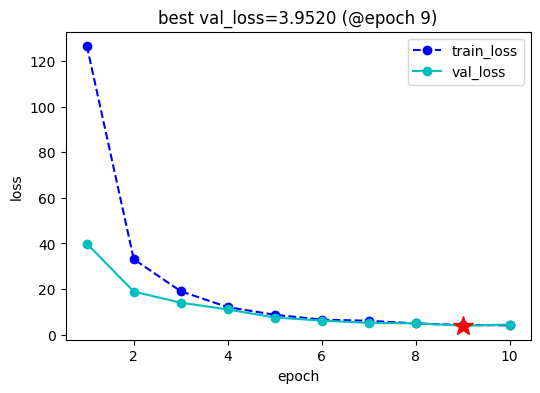

,epoch,train_loss,lr,val_loss
0,1,126.642150,0.0003,39.940200
1,2,33.113479,0.0003,18.908888
2,3,19.058241,0.0003,14.051171
3,4,12.098977,0.0003,11.086375
4,5,8.753611,0.0003,7.547747
5,6,6.630279,0.0003,6.215444
6,7,6.116859,0.0003,5.178206
7,8,4.957547,0.0003,5.005315
8,9,4.231384,0.0003,3.951993
9,10,4.123199,0.0003,4.449054


In [ ]:
net = create_model("vgg13", in_chans=2, num_classes=64, pretrained=False)
model = KerasModel(net, loss_fn=torch.nn.MSELoss())
model.fit(train_loader, test_loader, epochs=10)

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms.v2 import ToTensor, Compose, ToDtype
from timm.models import create_model
from torchkeras import KerasModel

In [ ]:
class AOShapingDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data.iloc[idx]
        img = sample.cam
        if img.ndim == 2:
            img = np.stack([img,img], axis=0) # shape(2, 144, 144)
        img = img.transpose([1,2,0])
        v = torch.from_numpy(sample.v).float()
        if self.transform:
            img = self.transform(img)
        return img, v
    
transforms = Compose([
    ToTensor(),
    ToDtype(torch.float32, scale=True),
])

dataset = AOShapingDataset(data, transform=transforms)
train_dataset, test_dataset = random_split(dataset, [0.8,0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

d:\Projects\TIFO\AO-shaping\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


<<<<<< ⚡️ cuda is used >>>>>>


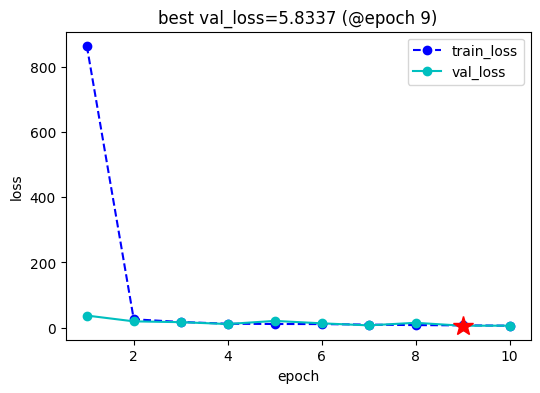

,epoch,train_loss,lr,val_loss
0,1,864.842475,0.001,37.052152
1,2,25.634922,0.001,19.242048
2,3,17.329020,0.001,16.717022
3,4,11.904527,0.001,11.050740
4,5,11.178387,0.001,20.618043
5,6,10.862955,0.001,13.199641
6,7,9.234418,0.001,6.912856
7,8,7.716194,0.001,14.794286
8,9,6.991038,0.001,5.833676
9,10,5.974992,0.001,6.039723


In [ ]:
net = create_model("vgg13", in_chans=2, num_classes=64, pretrained=False)
optimizer = Adam(net.parameters(), lr=1e-3)
model = KerasModel(net, optimizer=optimizer, loss_fn=torch.nn.MSELoss())
model.fit(train_loader, test_loader, epochs=10, patience=5, callbacks=[
    CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6),
])

In [ ]:
data1 = pd.read_pickle("7.pkl", compression="zip")
data1.head()

,J,v,diff,gamma,epoch,cam,wavefront,statics,delta
0,0.689699,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,1.0,-1,"[[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","{'min': -0.9791178703308105, 'max': 2.86273694...","{'min': -0.9791178703308105, 'max': 2.86273694...",1.0
1,0.686838,"[0.0, -9.999965528208592e-05, -9.9999655282085...",-0.002901,1.0,0,"[[[0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.9994064569473267, 'max': 2....",1.0
2,0.688441,"[0.0, -2.7834137531720704e-05, -2.783413753172...",-0.004927,1.0,1,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -1.0250056982040405, 'max': 2....",1.0
3,0.682161,"[0.0, -2.0968390072739293e-05, 0.0001006537270...",-0.001873,1.0,2,"[[[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.9689944386482239, 'max': 2....",1.0
4,0.695015,"[0.0, 5.8140019108567995e-05, 0.00029680328956...",0.002088,1.0,3,"[[[0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0...","[[[nan, nan, nan, nan, nan, nan, nan, nan, nan...","{'pos': {'min': -0.9919931292533875, 'max': 2....",1.0


<<<<<< ⚡️ cuda is used >>>>>>


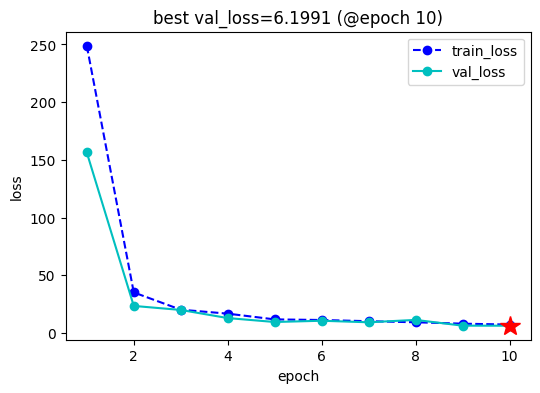

,epoch,train_loss,lr,val_loss
0,1,248.891088,0.000976,156.362595
1,2,35.063802,0.000905,23.365560
2,3,20.093350,0.000794,19.870242
3,4,16.671490,0.000655,12.838446
4,5,11.690707,0.000501,9.422349
5,6,11.157221,0.000346,10.510266
6,7,10.121357,0.000207,9.176100
7,8,9.190495,0.000096,11.240128
8,9,7.989606,0.000025,6.248763
9,10,7.179666,0.000001,6.199128


In [ ]:
net = create_model("vgg13", in_chans=2, num_classes=64, pretrained=False)
optimizer = Adam(net.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()
lr_schedule = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
model = KerasModel(net, optimizer=optimizer, loss_fn=loss_fn, lr_scheduler=lr_schedule)
model.fit(train_loader, test_loader, epochs=10, patience=5)

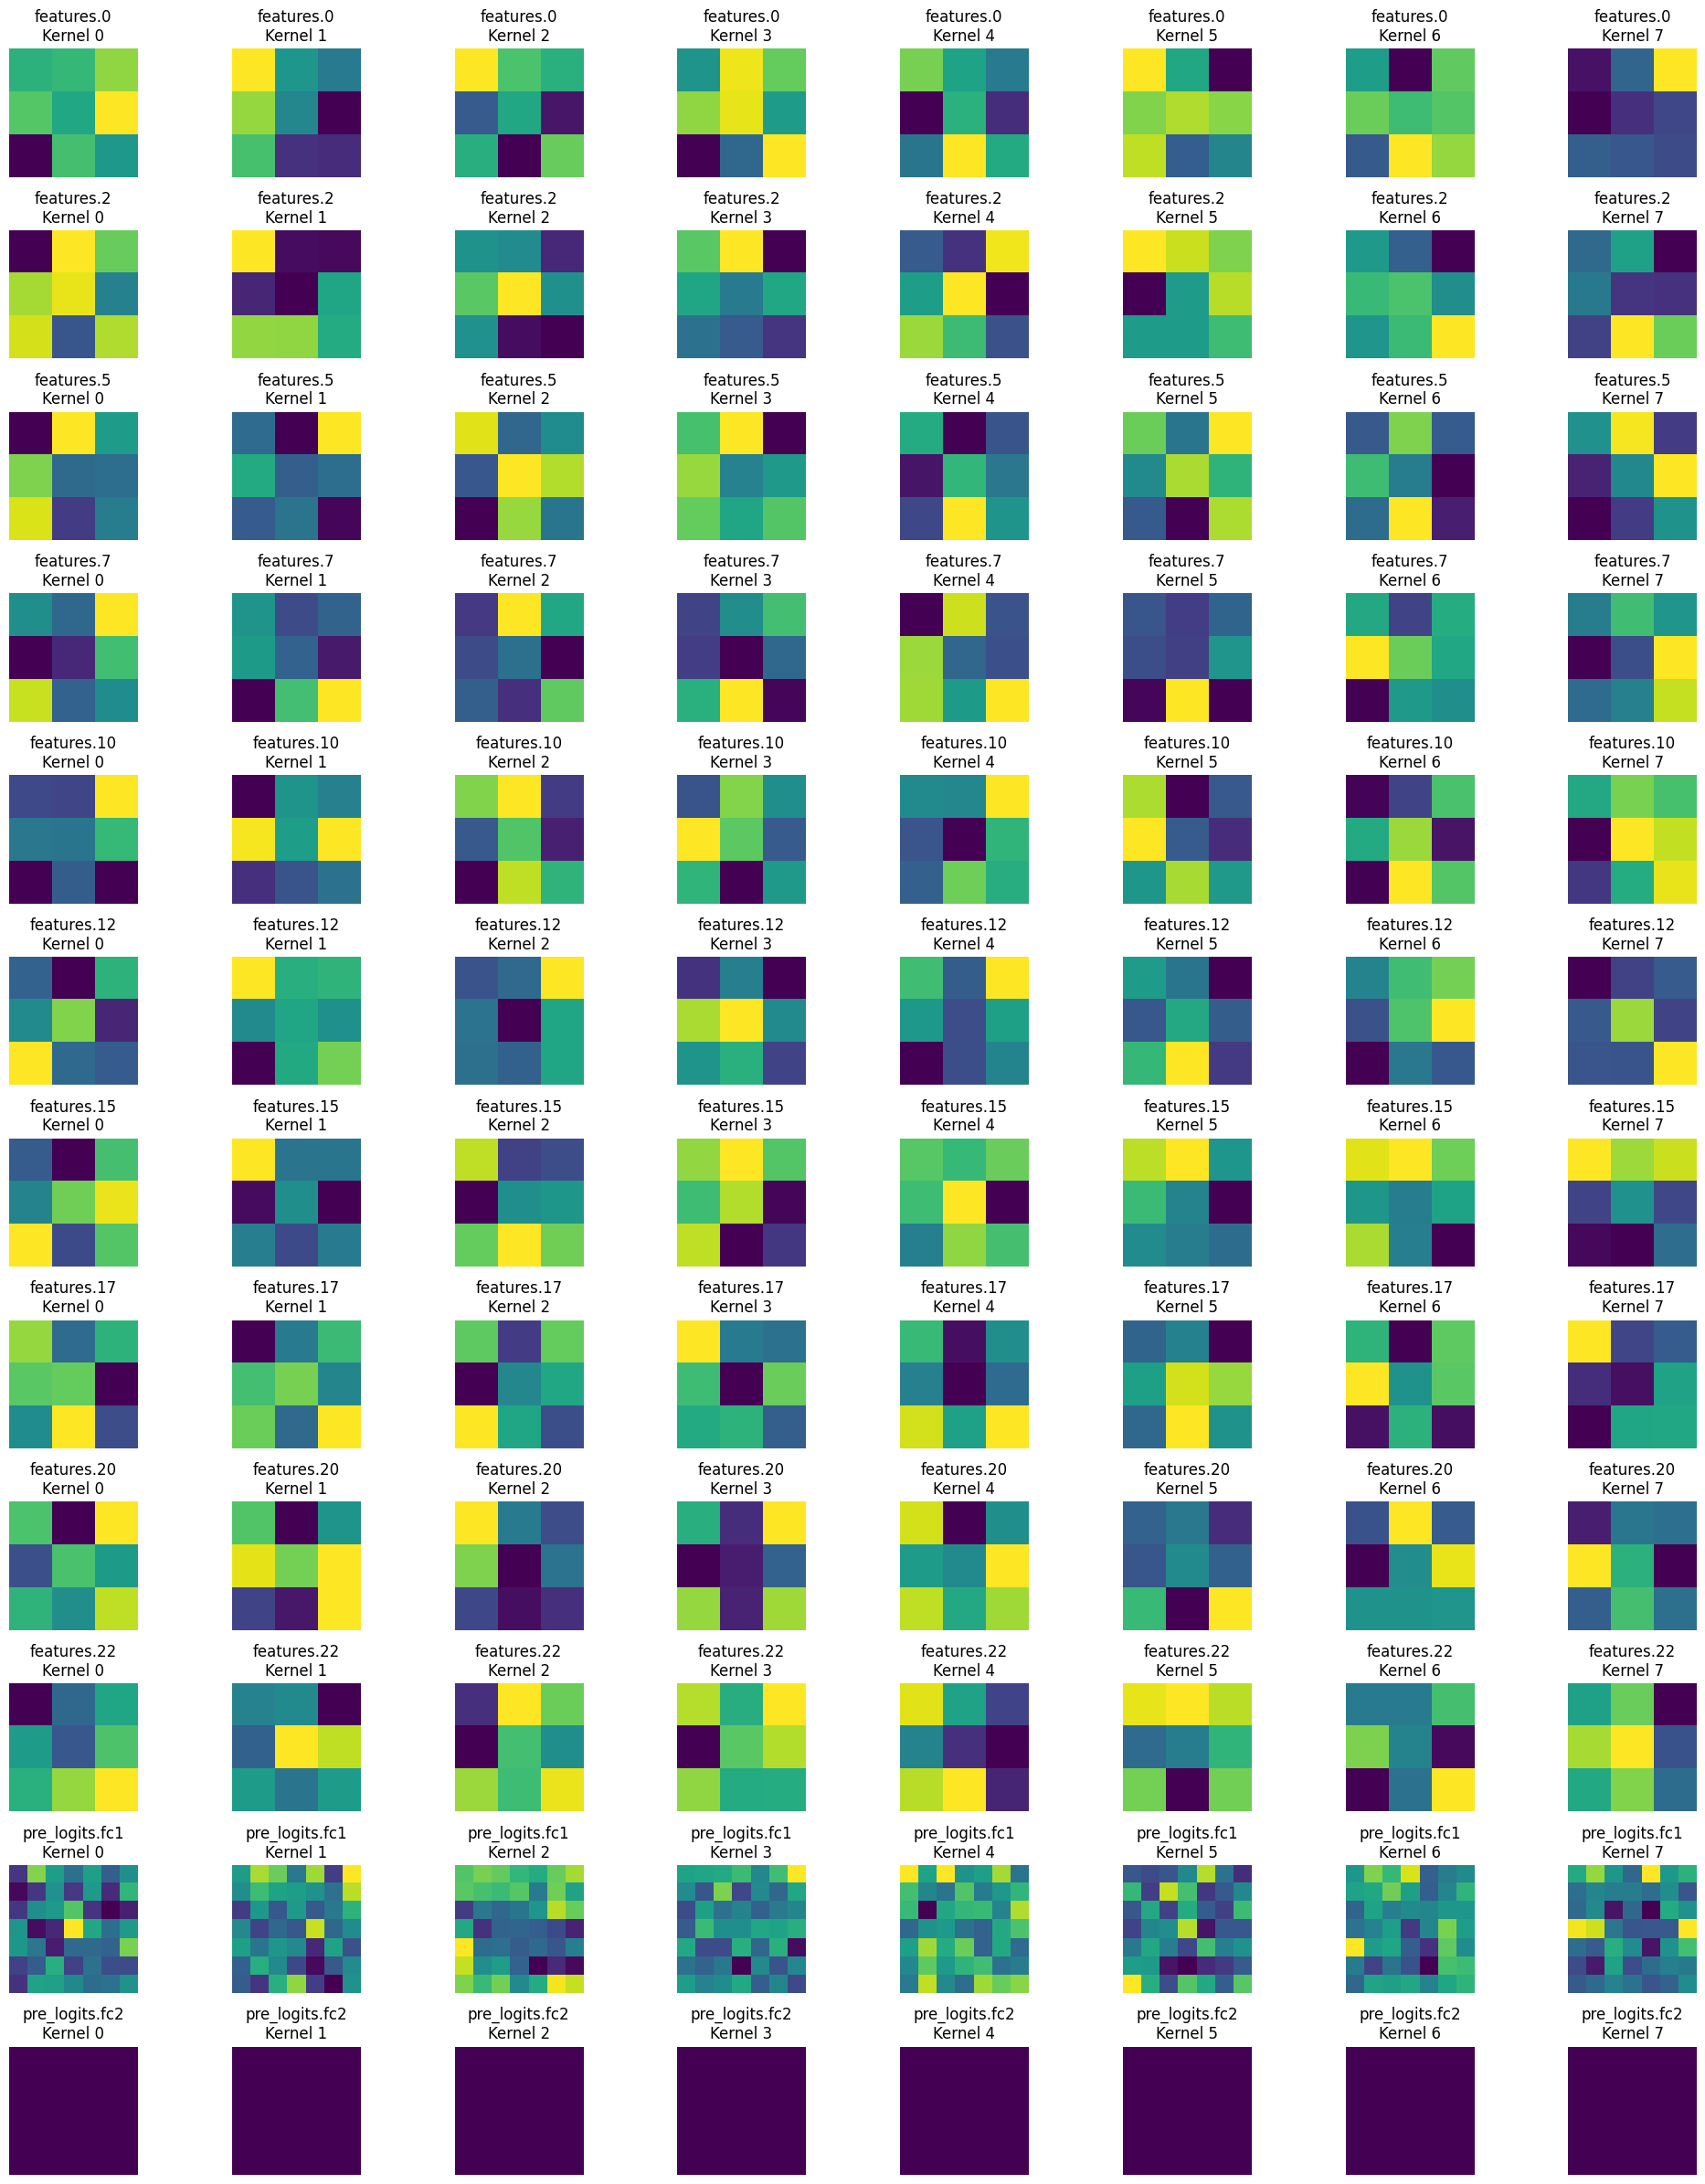

Visualizing feature maps for data1.iloc[0].cam


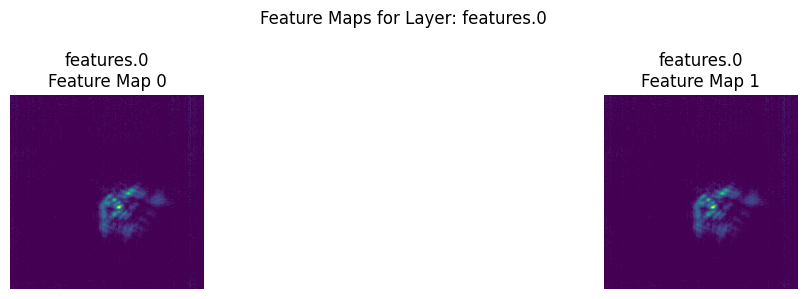

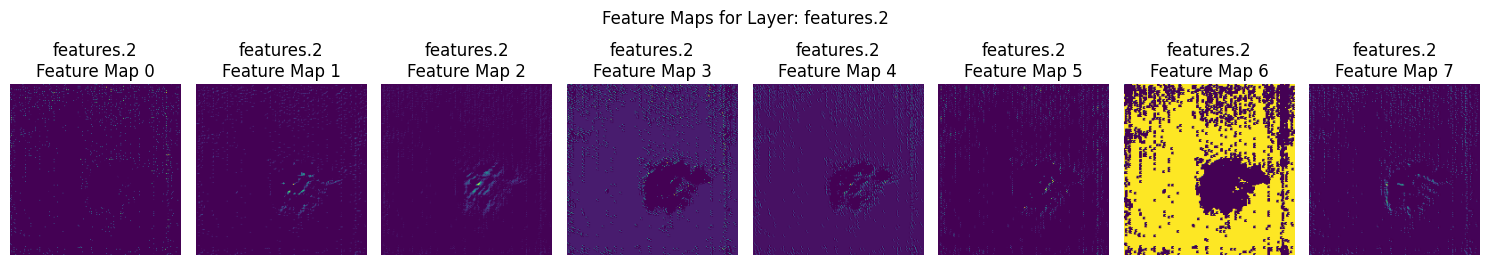

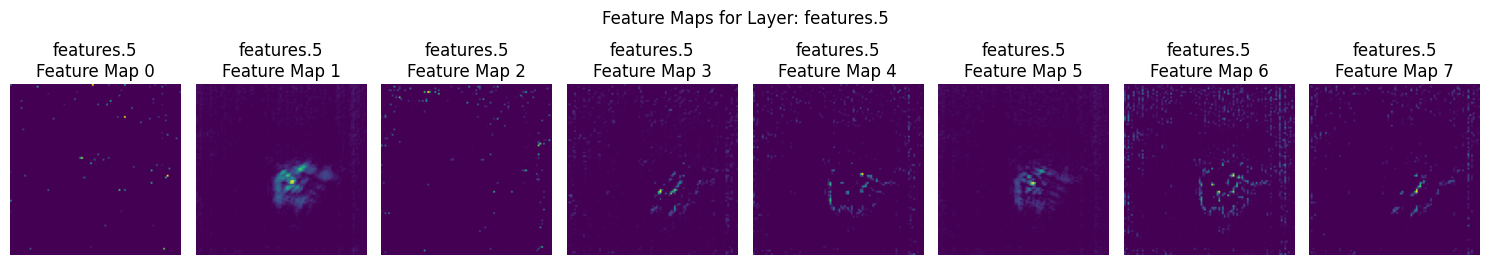

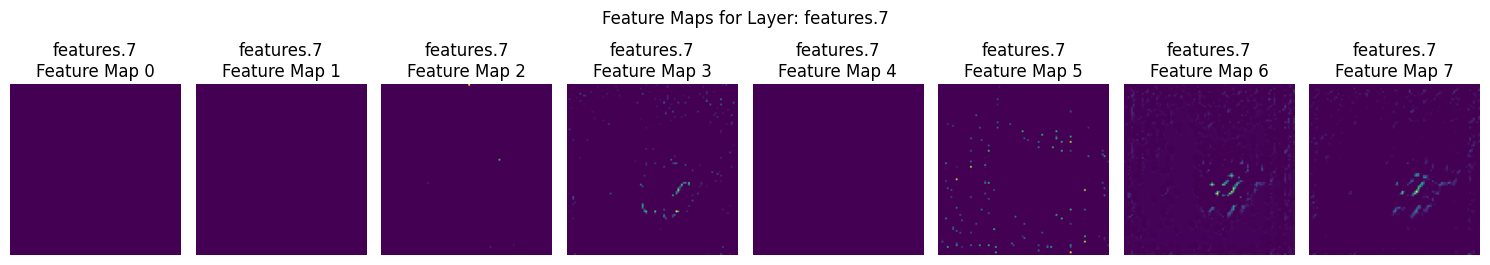

Visualizing feature maps for data2.iloc[0].cam


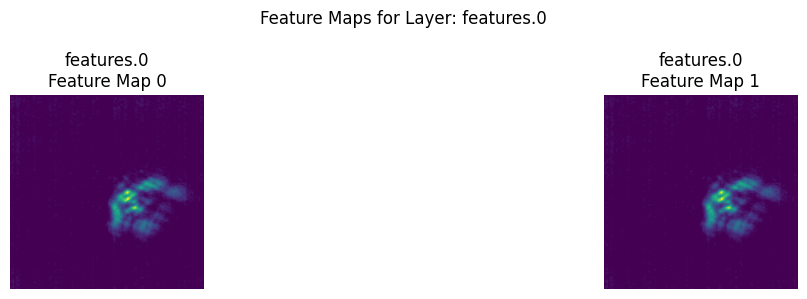

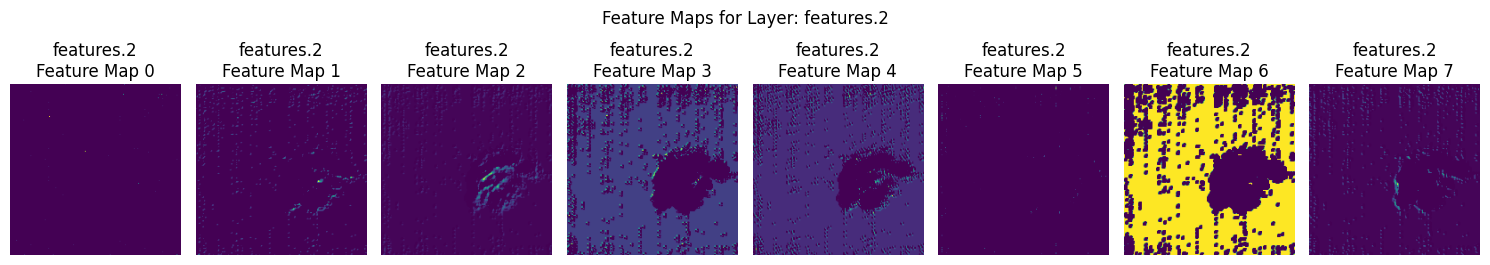

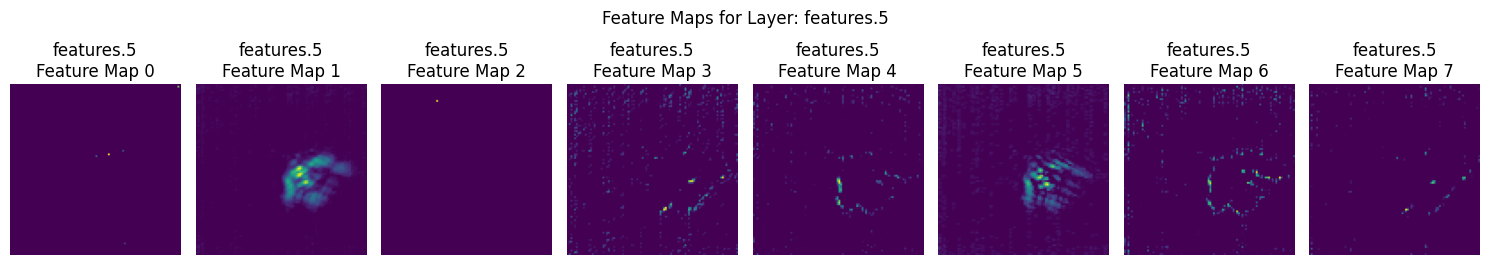

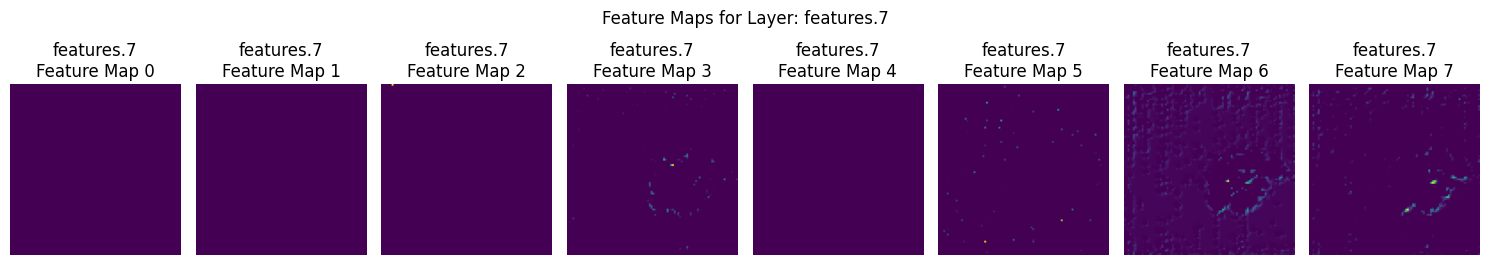

In [ ]:
def visualize_conv_kernels(model, layer_name="features"):
    """
    可视化VGG模型的卷积核
    
    Args:
        model: 训练好的VGG模型
        layer_name: 包含卷积层的模块名称，默认为"features"
    """
    conv_layers = []
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            conv_layers.append((name, module))
    
    if not conv_layers:
        print("No convolutional layers found in the model.")
        return
    
    # 计算总的子图数量
    total_subplots = sum(min(layer.weight.shape[0], 8) * min(layer.weight.shape[1], 8) 
                         for _, layer in conv_layers)
    
    # 创建足够大的图形
    fig, axes = plt.subplots(nrows=len(conv_layers), ncols=8, figsize=(20, 2*len(conv_layers)))
    if len(conv_layers) == 1:
        axes = [axes]
    
    for i, (name, layer) in enumerate(conv_layers):
        weights = layer.weight.data.cpu().numpy()
        
        # 显示前8个卷积核（如果有的话）
        for j in range(min(weights.shape[0], 8)):
            ax = axes[i][j] if len(conv_layers) > 1 else axes[j]
            # 显示第一个输入通道的权重
            kernel = weights[j, 0, :, :] if weights.shape[1] > 0 else weights[j, 0, :, :]
            im = ax.imshow(kernel, cmap='viridis')
            ax.set_title(f'{name}\nKernel {j}')
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig("conv_kernels.png")
    plt.show()

def visualize_feature_maps(model, input_tensor, layer_names=["features.0", "features.2", "features.5", "features.7"]):
    """
    可视化输入数据经过VGG模型各层后的特征图
    
    Args:
        model: 训练好的VGG模型
        input_tensor: 输入数据张量
        layer_names: 要可视化的层名称列表
    """
    activations = {}
    
    def hook_fn(module, input, output, name):
        activations[name] = input[0].detach().cpu().numpy()
    
    hooks = []
    for name, module in model.named_modules():
        if name in layer_names:
            hook = module.register_forward_hook(lambda module, input, output, n=name: hook_fn(module, input, output, n))
            hooks.append(hook)
    
    # 前向传播
    with torch.no_grad():
        _ = model(input_tensor.unsqueeze(0))
    
    # 移除钩子
    for hook in hooks:
        hook.remove()
    
    # 可视化特征图
    for layer_name in layer_names:
        if layer_name in activations:
            activation = activations[layer_name]
            num_features = min(activation.shape[1], 8)  # 最多显示8个特征图
            
            if num_features <= 0:
                continue
                
            fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(15, 3))
            if num_features == 1:
                axes = [axes]
            for i in range(num_features):
                ax = axes[i]
                feature_map = activation[0, i, :, :]
                im = ax.imshow(feature_map, cmap='viridis')
                ax.set_title(f'{layer_name}\nFeature Map {i}')
                ax.axis('off')
                
            plt.suptitle(f"Feature Maps for Layer: {layer_name}")
            plt.tight_layout()
            plt.savefig(f"feature_maps_{layer_name.replace('.', '_')}.png")
            plt.show()

# 可视化VGG卷积核
visualize_conv_kernels(net)

# 准备data1和data2的第一行数据
sample1_cam = data1.iloc[0].cam
sample2_cam = data2.iloc[0].cam

# 处理数据以匹配模型输入要求
def prepare_image(img):
    if img.ndim == 2:
        img = np.stack([img, img], axis=0)  # shape(2, 144, 144)
    img = img.transpose([1, 2, 0])  # 转换为(H, W, C)
    img_tensor = transforms(img)  # 应用变换
    return img_tensor

sample1_tensor = prepare_image(sample1_cam)
sample2_tensor = prepare_image(sample2_cam)

# 可视化data1.iloc[0].cam经过卷积核之后的图片
print("Visualizing feature maps for data1.iloc[0].cam")
visualize_feature_maps(net, sample1_tensor)

# 可视化data2.iloc[0].cam经过卷积核之后的图片
print("Visualizing feature maps for data2.iloc[0].cam")
visualize_feature_maps(net, sample2_tensor)